# 库导入

In [1]:
# 库索引
import numpy as np
import matplotlib.pyplot as plt
#%matplotlib inline
from astropy.cosmology import FlatLambdaCDM
from astropy import constants as const
#import camb
#from camb import model, initialpower
from scipy.integrate import quad

#import mpmath as mp
import astropy.units as u
from astropy.cosmology import z_at_value
# import pickle
from matplotlib.ticker import FuncFormatter # 图表格式化库

from typing import Tuple # 类型提示库
import pandas as pd # 使用pandas读取信息

# from gapp import dgp # GP拟合方法库

import csv
from scipy.interpolate import interp1d

from pycbc.waveform import get_fd_waveform, get_fd_waveform_sequence
from pycbc.types import TimeSeries,FrequencySeries, Array

# 多线程运算库
from multiprocessing import Pool

# from pathos.multiprocessing import ProcessingPool as Pool



/Users/saki/Environment/miniconda3/envs/python/lib/python3.13/site-packages/pycbc/types/array.py:36: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal as _lal


# 全局常量初始化

In [2]:
# 定义全局常量
np.random.seed(2030)  # 固定随机数种子
# 光速
c_light=const.c.to(u.km/u.s).value  # 定义天文学中的光速
c_mpc_yr=const.c.to(u.Mpc/u.yr) # 将光速转化为Mpc/year 的情况
c_kms=const.c.to(u.km/u.s).value

# 万有引力常数
constG=const.G.to(u.Mpc**3/(u.Msun*u.s**2)).value # 是万有引力常数
constc=const.c.to(u.Mpc/u.s).value # 转换换单位为 Mpc³ / (Msun·s²)，方便天体物理和宇宙学单位下使用
 
#ACDM标准宇宙学模型=cosmo内储存了一些常量+cosmo可以计算很多宇宙学（依据其所储存的常量）量
cosmo=FlatLambdaCDM(H0=67.716454,Om0=0.31035540,Tcmb0=2.7255, m_nu = [0.06, 0.0, 0.0] * u.eV, Neff=3.046)

# RT修正引力理论参数
RT_Xi = 1.67
RT_n = 1.94

print(constG)
# print(cosmo.luminosity_distance(1))
# print(cosmo.age(0))
# print(cosmo.hubble_time)
# print(cosmo.H(0).to(u.Gyr**(-1)))
# print(z_at_value(cosmo.luminosity_distance,40*u.Mpc))

4.517103049894965e-48


# 红移分布撒点采样功能函数

In [3]:
# 读取CSV文件并输出为NumPy二维数组
# 输入：CSV文件路径 -> 输出：原始数据的NumPy二维数组data_array[][]
def read_csv_to_numpy(file_path: str) -> np.ndarray:
    df = pd.read_csv(file_path)  # 文件路径可以是相对路径或绝对路径
    data_array = df.to_numpy()
    return data_array # 这里返回的是一个二维Numpy数组

In [4]:
# 绘制二维数组[][2]数据直方图
# 输入：(（csv文件地址）二维数组data_array[..][3], 图例标签，点线样式，误差条颜色) -> 输出：无（图像）
# def plot_histogram_from_csv(file_path: str):
def plot_histogram_from_csv(file_path, z_min=None, z_max=None, bins=10):
    data = read_csv_to_numpy(file_path)  # 替换成你的文件路径

    z = data[:, 0]  # 假设 z 在第一列
    cnt = data[:, 1]  # 假设 cnt 在第二列

    # 自动设置 z 范围
    if z_min is None:
        z_min = z.min()
    if z_max is None:
        z_max = z.max()

    # 生成 bin 边界
    bin_edges = np.linspace(z_min, z_max, bins + 1)

    # 统计每个 bin 的总计数
    hist, _ = np.histogram(z, bins=bin_edges, weights=cnt)

    # 绘制直方图
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    width = bin_edges[1] - bin_edges[0]

    plt.figure(figsize=(10,6))
    plt.bar(bin_centers, hist, width=width, color='skyblue', edgecolor='black')
    plt.xlim(0,0.5)
    plt.ylim(bottom=0)
    plt.xlabel('z')
    plt.ylabel('Count')
    plt.title(f'Histogram of counts vs z (bins={bins})')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()

    # 绘制直方图，按 z 的区间统计，cnt 用作权重
    # plt.figure(figsize=(10,6))

    # # 这里用 bins=10，你可以根据需要调整区间数
    # plt.hist(z, bins=10, weights=cnt, color='skyblue', edgecolor='black')

    # plt.xlabel('z')
    # plt.ylabel('Count')
    # plt.title('Histogram of counts vs z')
    # plt.grid(axis='y', linestyle='--', alpha=0.7)
    # plt.show()

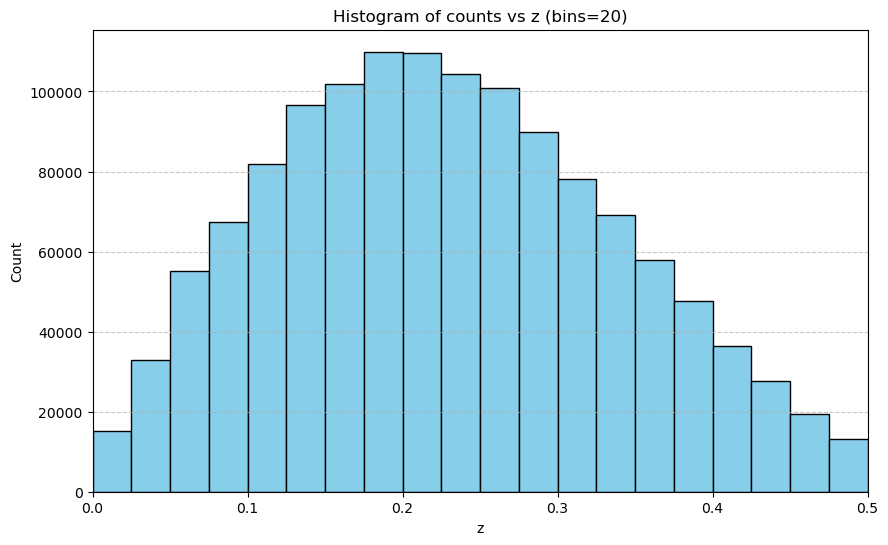

In [5]:
plot_histogram_from_csv("Data/results_histogram.csv",0,0.5,20)

In [6]:
# 输入： (二维红移数组（csv文件）,输出文件名称，总抽取样本数) -> 输出：无（抽样红移分布数据csv表）
def stratified_sampling_from_histogram(csv_file, output_file, N_total, z_min=None, z_max=None, bins=10, seed=None):
    """
    从直方图 CSV 文件进行加权分层抽样
    csv_file: 输入 CSV 文件，包含 'z' 和 'cnt' 两列，z 为条形中值
    output_file: 输出 CSV 文件
    N_total: 总共要抽取的样本数
    z_min, z_max: 可选，定义直方图 z 范围
    bins: 分箱数（可选）
    seed: 随机种子（可选）
    """
    if seed is not None:
        np.random.seed(seed)
    
    # 读取 CSV
    df = pd.read_csv(csv_file)
    z = df['z'].values
    cnt = df['cnt'].values

    # 设置 z 范围
    if z_min is None:
        z_min = z.min()
    if z_max is None:
        z_max = z.max()

    # 生成 bin 边界
    bin_edges = np.linspace(z_min, z_max, bins + 1)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    width = bin_edges[1] - bin_edges[0]

    # 按 bin 中心找到每个 z 属于哪一个 bin
    bin_indices = np.digitize(z, bin_edges) - 1
    bin_indices[bin_indices == bins] = bins - 1  # 边界处理

    # 计算每个 bin 的总权重
    bin_weights = np.zeros(bins)
    for i, w in zip(bin_indices, cnt):
        bin_weights[i] += w

    # 根据权重分配样本数（四舍五入）
    bin_sample_counts = np.round(N_total * bin_weights / bin_weights.sum()).astype(int)

    # 在每个 bin 内随机生成样本
    samples = []
    for i, n_samples in enumerate(bin_sample_counts):
        if n_samples > 0:
            # 均匀分布在 bin 区间
            s = np.random.uniform(bin_edges[i], bin_edges[i+1], n_samples)
            samples.append(s)
    samples = np.concatenate(samples)

    # 保存到 CSV
    pd.DataFrame({'z_sampled': samples}).to_csv(output_file, index=False)
    print(f"生成 {len(samples)} 个样本，已保存到 {output_file}")


In [7]:
# stratified_sampling_from_histogram(
#     csv_file="Data/results_histogram.csv",
#     output_file="sampled_points.csv",
#     N_total=5000,
#     z_min=0,
#     z_max=0.5,
#     bins=10,
#     seed=42
# )

# 红移分布生成基础数据 Redshift Distribution of merge rate

## 考虑不同time-delay情形的红移分布

In [8]:
# 本地合并率密度 常量定义。三个数是你的模拟设置开关。它们决定了你的虚拟宇宙中到底“有多挤”
rm_f0=662 # 中子星多，但信号弱。
rm_g0=920 # 一个非常乐观的参数，用来产生大量数据以减小统计误差。
rm_bh0=50 # 黑洞少，但信号强。

In [9]:
#  不考虑时间延迟的情形 no-time-delay case 
def Rm0(z):
    if 0<=z<1:
        return 1+2*z
    if 1<=z<5:
        return 3/4*(5-z)
    else:
        return 0

def norm_Rm0(z):
    return rm_g0/Rm0(0)*Rm0(z)

#print(norm_Rm0(0))

v_norm_Rm0=np.vectorize(norm_Rm0)


def Rz0(z):
    return 4*np.pi*(cosmo.comoving_distance(z).to(u.Gpc).value)**2*c_light/(cosmo.H(z).to(u.km / (u.Gpc*u.s)).value*(1+z))*norm_Rm0(z)


##################################################################################################################################################
##################################################################################################################################################
# 考虑time-delay的情形 time-delay case  ：幂律延迟 power-law td^(-1)
## 来自于论文 1409.2462 Eq.1
def Rf(z):
    nu=0.36
    a=1.92
    b=1.5
    zm=2.6
    return nu*(a*np.exp(b*(z-zm)))/(a-b+b*np.exp(a*(z-zm)))


def Rm(z):
    rm=quad(lambda zf: 1/((cosmo.H(zf).value)*(1+zf))*Rf(zf)/(cosmo.lookback_time(zf).value-cosmo.lookback_time(z).value),
        z_at_value(cosmo.lookback_time, (cosmo.lookback_time(z).value+0.02) * u.Gyr, 0, 100), 200)[0]
    return rm


def norm_Rm(z):
    return rm_g0/Rm(0)*Rm(z)

#print(norm_Rm(0))

v_norm_Rm=np.vectorize(norm_Rm)

def Rz(z):
    rz=4*np.pi*(cosmo.comoving_distance(z).to(u.Gpc).value)**2*c_light/(cosmo.H(z).to(u.km / (u.Gpc*u.s)).value*(1+z))*norm_Rm(z)
    return rz

##################################################################################################################################################
##################################################################################################################################################
# 考虑time-delay的情形 time-delay case  ：指数衰减  exponential time-dela   1/tau*exp((tf-tm)/tau)
## 来自于论文 1403.0007 Eq.15
def psi_MD(z):
    a=2.7
    b=5.6
    c=2.9
    phi0=0.015
    return phi0*(1+z)**a/(1+((1+z)/c)**b)

##  来自论文1808.00901 Eq.2 and 5
def Rm_MD(z):
    tau=0.1
    return quad(lambda zf: 1/((cosmo.H(zf).value)*(1+zf))*psi_MD(zf)/
        tau*np.exp(-(cosmo.lookback_time(zf).value-cosmo.lookback_time(z).value)/tau),z, np.inf)[0]

def norm_Rm_MD(z):
    return rm_g0/Rm_MD(0)*Rm_MD(z)
# print(norm_Rm_MD(0))

v_norm_Rm_MD=np.vectorize(norm_Rm_MD)

def Rz_MD(z):
    rz=4*np.pi*(cosmo.comoving_distance(z).to(u.Gpc).value)**2*c_light/(cosmo.H(z).to(u.km / (u.Gpc*u.s)).value*(1+z))*norm_Rm_MD(z)
    return rz

# A=Rz_MD(0.1)
# print(A)

## 模拟引力波事件数据的采样(HLVKI)

In [10]:
# 根据红移分布函数，计算红移小区间内“模拟观测到”的引力波事件数量。
# 输入：红移分布函数（Rz0(z)或Rz(z)或Rz_MD(z)）, 区间步长，区间数量 -> 输出：一维numpy整数数组（每个红移小区间内“模拟观测到”的引力波事件数量）
def generate_zn_samples(z_distribution_func,step=0.01,n_range=20):
    znlist0=[quad(z_distribution_func,step*i,step*(i+1))[0] for i in range(n_range)] # 积分计算每个红移区间的“理论期望数” 带小数
    znlist1=[int(znlist0[i]) for i in range(len(znlist0))] # 对理论值进行向下取整
    znlist1=np.array(znlist1)
    znlist2=np.zeros(len(znlist0)) # 决定那些“小数点后的数字”是否能变成一个真实的信号：这是一种伯松抽样（Poisson Sampling）的简化实现
    for i in range(len(znlist2)):
        a=np.random.random()
        if znlist0[i]-znlist1[i]>a:
            znlist2[i]=znlist1[i]+1 # 向上取整
        else:
            znlist2[i]=znlist1[i] # 保持向下取整
    znlist=np.array([int(znlist2[i]) for i in range(len(znlist2))]) # 将结果汇总并转回整数类型。
    return znlist

# znlist = generate_zn_samples(Rz_MD,step=0.01,n_range=20)
# print(znlist)


In [42]:
# 将之前generate_zn_samples算出的“每个区间有几个源”的数量，转化为每个源具体的红移坐标。
# 输入：红移分布函数, 区间步长，区间数量 -> 输出：一维numpy数组（每个元素是一个引力波事件的红移）
def generate_z_samples(z_distribution_func,step=0.01,n_range=20):
    znlist=generate_zn_samples(z_distribution_func,step,n_range)
    zlist=np.array([])
    for i, n in enumerate(znlist):
        z=np.random.uniform(step*i,step*(i+1),n)
        zlist=np.concatenate((zlist,z),axis=None)
    zlist.sort()
    print(f"{zlist}，总共模拟了{len(zlist)}个源")
    return zlist

# zlist = generate_z_samples(Rz_MD,step=0.01,n_range=5)
# print(zlist)

In [12]:
# 根据生成的红移样本坐标zlist，去组成更完整的模拟引力波事件数据
# 输入：使用引力模型类型，生成的红移坐标 ->输出：二维numpy数组，每行是一个模拟引力波事件的参数（Mc, eta, dL, iota, theta, phi, psi, tc, phic）
def generate_gw_events(zlist,GW_type="GR"):
    m1=np.random.uniform(1,2,len(zlist)) #Msun

    m2=np.random.uniform(1,2,len(zlist))#Msun
    cosiota=np.random.uniform(0,1,len(zlist))  #http://keatonb.github.io/archivers/uniforminclination
    iota=np.arccos(cosiota)
    theta=np.random.uniform(0,np.pi,len(zlist))
    # cosphi=np.random.uniform(-1,1,len(zlist)) #https://www.bogotobogo.com/Algorithms/uniform_distribution_sphere.php
    # phi=np.arccos(cosphi)
    phi = np.random.uniform(0,2*np.pi,len(zlist))
    
    for i in range(len(zlist)):
        s=np.random.random()
        if s>0.5:
            phi[i]=2*np.pi-phi[i]
    psi=np.random.uniform(0,np.pi*2,len(zlist))
    Mc=(m1*m2)**(3/5)/(m1+m2)**(1/5)*(1+zlist) #Msun
    eta = (m1 * m2) / (m1 + m2)**2
    # Maggiore GW I page 175
    # fmax=[2*constc**3/(6*np.sqrt(6)*2*np.pi*constG*(m1[i]+m2[i]))/(1+zlist[i]) for i in range(len(zlist))]
    # 1907.01487 Eq.2.8
    # F2_L=(1+cosiota**2)**2/4*(np.vectorize(Fp_L)(theta,phi,psi))**2+cosiota**2*(np.vectorize(Fc_L)(theta,phi,psi))**2
    #F2_T=(1+cosiota**2)**2/4*(np.vectorize(Fp_T)(theta,phi,psi))**2+coseta**2*(np.vectorize(Fc_T)(theta,phi,psi))**2
    if GW_type=="GR":
        dL=cosmo.luminosity_distance(zlist).value
    elif GW_type == "RT":
        dL=cosmo.luminosity_distance(zlist).value*(RT_Xi + (1 - RT_Xi)/((1 + zlist)**RT_n)) # RT模型的luminosity distance需要额外乘以一个(1+z)的因子
    else:
        dL=cosmo.luminosity_distance(zlist).value

    tc = np.zeros(len(zlist))    # 并合时刻令为 0
    phic = np.zeros(len(zlist))  # 并合相位通常也令为 0
    generate_gw_events = np.column_stack((zlist,Mc,eta,dL, iota, theta, phi, psi,tc,phic))

    return generate_gw_events

# gw_events = generate_gw_events(generate_z_samples(Rz_MD,step=0.01,n_range=20),GW_type="GR")
# print(gw_events)

# 探测器灵敏度曲线/噪声曲线/噪声功率谱密度（PSD）

In [13]:
# 得到Sn的PSD插值函数形式
# 主要输入：探测器名字 -> 输出：一个Sn的PSD插值
def get_detector_psd(detector="LISA"):
    """
    返回指定探测器的噪声 PSD 插值函数
    输入: 
        detector: 探测器类型, 支持 "LISA", "TianQin", "aLIGO"
        c_light: 光速 (km/s)
    返回:
        interp_psd(f): 可调用函数, 输入频率 f (Hz), 返回幅度谱 sqrt(Sn(f))
    """

    # 频率数组
    f_array = np.arange(1e-4, 1.0, 0.0001)  # 可根据探测器调整范围

    if detector == "LISA":
        # ------------------ LISA PSD ------------------
        # 加速度噪声
        Sacc = 9e-30 * 1e-6 / (2*np.pi*f_array)**4 * (1 + (6e-4/f_array)**2 * (1 + (2.22e-5/f_array)**8)) 
        
        # 其他噪声
        Sother = 8.899e-23 * 1e-6

        A = 3/20 * 3.2665e-44
        s1, alpha = 3014.3, 1.183
        s2, kappa = 2957.7, 2.0928e-3
        
        # 混合白矮星背景噪声 
        Sconf = A/2 * np.exp(-s1*f_array**alpha) * f_array**(-7/3) * (1 - np.tanh(s2*(f_array - kappa)))
        L = 2.5e6

        # 总噪声
        Sn_total = (4*Sacc + Sother)/L**2 * (1 + (2*f_array*L/(0.41*c_light))**2) + Sconf

    elif detector == "TianQin":
        # ------------------ TianQin PSD ------------------
        L = 1.73e5  # km
        Sacc = (3e-15)**2 * (1 + (0.4e-3/f_array)**2) * (1 + (f_array/0.008)**4)
        Sother = (1e-12)**2
        Sn_total = (20/(3*L**2)) * (Sother + 4*Sacc/(2*np.pi*f_array)**4)

    elif detector == "aLIGO":
        # ------------------ aLIGO PSD 简化版 ------------------
        f0 = 215.0
        x = f_array / f0
        Sn_total = 1e-49 * (x**(-4.14) - 5*x**(-2) + 111*(1 - x**2 + x**4/2)/(1 + x**2/2))

    else:
        raise ValueError(f"Unknown detector type: {detector}")
    
    # 幅度谱
    psd = np.sqrt(Sn_total)
    psd_array = np.column_stack((f_array, psd))
    # 返回插值函数
    return lambda f: np.interp(f, psd_array[:,0], psd_array[:,1])


def Sacc(f):
    return 9*10**(-30)*10**(-6)/(2*np.pi*f)**4*(1+(6*10**(-4)/f)**2*(1+(2.22*10**(-5)/f)**8))

def Sother(f):
    return 8.899*10**(-23)*10**(-6)

def Sconf(f):
    A=3/20*3.2665*10**(-44)
    s1=3014.3
    alpha=1.183
    s2=2957.7
    kappa=2.0928*10**(-3)
    return A/2*np.exp(-s1*f**alpha)*f**(-7/3)*(1-np.tanh(s2*(f-kappa)))

def Sn(f):
    L=2.5*10**6
    return (4*Sacc(f)+Sother(f))/L**2*(1+(2*f*L/(0.41*c_light))**2)+Sconf(f)


In [14]:
def Sn_ETCE(f,detector="ET"):
    if detector == "ET":
        psd_ET=np.loadtxt('psd_ET.txt')
        def interp_psd_ET(f):
            return np.interp(f,psd_ET[:,0],psd_ET[:,3])
        return interp_psd_ET(f)**2
    elif detector == "CE":
        psd_CE=np.loadtxt('psd_CE.txt')
        def interp_psd_CE(f):
            return np.interp(f,psd_CE[:,0],psd_CE[:,3])
        return interp_psd_CE(f)**2
    else:
        raise ValueError(f"Unknown detector type: {detector}")


# psd_ET=np.loadtxt('psd_ET.txt')

# def interp_psd_ET(f):
#     return np.interp(f,psd_ET[:,0],psd_ET[:,3])

# def SnET(f):
#     return interp_psd_ET(f)**2

# plt.plot(psd_ET[:,0],psd_ET[:,3],label='ET-D')

# plt.xlabel(r'Frequency (Hz)')
# plt.ylabel(r'$\sqrt{Sn(f)}$ $(\rm Hz^{-1/2})$')
# plt.xlim(10**-5,10**4)
# plt.ylim(10**-25,10**-15)
# plt.xscale('log')
# plt.yscale('log')
# plt.legend()
# plt.show()

# 生成频域波形$h$：响应函数+时间延迟函数

### 功能函数

In [46]:
# 进度条函数
def bar(i, n):
    i = i + 1
    percent = i / n * 100
    print(
        '\r[' +
        '#' * int(40 * i / n) +
        ' ' * (40 - int(40 * i / n)) +
        f'] {percent:6.2f}%',
        end=''
    )

In [16]:
# time of frequency
def tf(f,Mc,tc):    #the circular case
    return tc-5*(8*np.pi*f)**(-8/3)*(constG*Mc)**(-5/3)*constc**5

#fsun=1/((1*u.yr).to(u.s).value)
fearth=1/((1*u.day).to(u.s).value)
def phiEA_t(t,phiEA0):
    return 2*np.pi*fearth*t+phiEA0

### 探测器响应函数

In [17]:
# 根据探测器类型生成响应函数
# 输入 : 探测器名字 -> 输出 : 多个函数和一个数值组成的字典
def get_detector_response(detector="LISA"):
    """
    根据探测器类型返回相应的时频关系和响应函数
    输入:
        detector: 探测器名称, 支持 "LISA", "TianQin" (可扩展)
    返回:
        fm: 调制频率 (Hz)
        tf_func: 时频关系函数 tf(tc, f, Mc)
        tfe_func: 考虑偏心率的时频函数 tfe(tc, f, Mc)
        alphat_func: 调制相位函数 alphat(t)
        Dp_func: 极化响应 Dp(t, theta, phi, lam)
        Dc_func: 极化响应 Dc(t, theta, phi, lam)
        Fp_func: 幅度响应 F+ (f, Mc, theta, phi, psi, tc, lam)
        Fc_func: 幅度响应 Fx (f, Mc, theta, phi, psi, tc, lam)
    """

    # ---------------- 分支选择 ----------------
    if detector == "LISA":
        fm = 1/((1*u.yr).to(u.s).value)  # LISA 基本调制频率

        # 时频关系函数
        def tf(tc, f, Mc):
            return tc - 5*(8*np.pi*f)**(-8/3) * (constG*Mc)**(-5/3) * constc**5

        def tfe(tc, f, Mc):
            poly = (3.35699e-55 - 7.50015e-50*f + 3.99113e-45*f**2 + 4.33106e-40*f**3
                    - 7.76808e-35*f**4 + 5.32154e-30*f**5 - 2.0606e-25*f**6 + 4.75385e-21*f**7
                    - 6.04605e-17*f**8 + 2.66042e-13*f**9 + 1.85397e-9*f**10
                    - 2.02688e-8*f**11 - 0.375*f**12)
            return tc + 5*constG*Mc/(96*(np.pi*constG*Mc)**(8/3))*constc**5*poly/f**(44/3)

    elif detector == "TianQin":
        fm = 1/(365*u.day.to(u.s))  # TianQin 基本调制频率
        # 可以定义专门的时频关系，下面用LISA形式占位
        def tf(tc, f, Mc):
            return tc - 5*(8*np.pi*f)**(-8/3) * (constG*Mc)**(-5/3) * constc**5

        def tfe(tc, f, Mc):
            poly = (3.35699e-55 - 7.50015e-50*f + 3.99113e-45*f**2 + 4.33106e-40*f**3
                    - 7.76808e-35*f**4 + 5.32154e-30*f**5 - 2.0606e-25*f**6 + 4.75385e-21*f**7
                    - 6.04605e-17*f**8 + 2.66042e-13*f**9 + 1.85397e-9*f**10
                    - 2.02688e-8*f**11 - 0.375*f**12)
            return tc + 5*constG*Mc/(96*(np.pi*constG*Mc)**(8/3))*constc**5*poly/f**(44/3)

    else:
        raise ValueError(f"Unknown detector type: {detector}")

    # ---------------- 通用响应函数 ----------------
    def alphat(t):
        return 2*np.pi*fm*t - 1/12*np.pi

    def Dp(t, theta, phi, lam):
        factor = np.sqrt(3)/64
        term1 = -36*np.sin(theta)**2 * np.sin(2*alphat(t) - 2*lam)
        term2 = (3 + np.cos(2*theta)) * (
            np.cos(2*phi)*(9*np.sin(2*lam) - np.sin(4*alphat(t)-2*lam)) +
            np.sin(2*phi)*(np.cos(4*alphat(t)-2*lam)-9*np.cos(2*lam))
        )
        term3 = -4*np.sqrt(3)*np.sin(2*theta) * (
            np.sin(3*alphat(t)-2*lam-phi) - 3*np.sin(alphat(t)-2*lam+phi)
        )
        return factor * (term1 + term2 + term3)

    def Dc(t, theta, phi, lam):
        factor = 1/16
        term1 = np.sqrt(3)*np.cos(theta)*(9*np.cos(2*lam-2*phi) - np.cos(4*alphat(t)-2*lam-2*phi))
        term2 = -6*np.sin(theta)*(np.cos(3*alphat(t)-2*lam-phi) + 3*np.cos(alphat(t)-2*lam+phi))
        return factor * (term1 + term2)

    def Fp(f, Mc, theta, phi, psi, tc, lam):
        return 0.5*(np.cos(2*psi)*Dp(tf(tc,f,Mc), theta, phi, lam) - 
                    np.sin(2*psi)*Dc(tf(tc,f,Mc), theta, phi, lam))

    def Fc(f, Mc, theta, phi, psi, tc, lam):
        return 0.5*(np.sin(2*psi)*Dp(tf(tc,f,Mc), theta, phi, lam) + 
                    np.cos(2*psi)*Dc(tf(tc,f,Mc), theta, phi, lam))

    return {
        "fm": fm,
        "tf": tf,
        "tfe": tfe,
        "alphat": alphat,
        "Dp": Dp,
        "Dc": Dc,
        "Fp": Fp,
        "Fc": Fc
    }


def get_detector_response2(detector="ET",type = None):
    if detector == "ET":
        if type == "1":
            def Fp_ET1 (f,Mc,tc,theta,phi,psi):
                t=tf(f,Mc,tc)
                phiEA=phiEA_t(t,(4+55/60)*np.pi/180)
                ET1Fp0=(-0.10478204441849033 + np.cos(2*(phi - phiEA))*(-0.45771795558150985 - 0.15257265186050328*np.cos(2*theta)) + np.cos(2*theta)*(0.10478204441849033 + 0.08574865294897005*np.sin(2*(phi - phiEA))) + 0.25724595884691015*np.sin(2*(phi - phiEA)) + (-0.18130721949311185*np.cos(phi - phiEA) + 0.13215019511808676*np.sin(phi - phiEA))*np.sin(2*theta))
                ET1Fc0=(-0.3437619782425746*np.cos(2*(phi - phiEA))*np.cos(theta) - 0.6113445953704968*np.cos(theta)*np.sin(2*(phi - phiEA)) + (-0.26330154256052474*np.cos(phi - phiEA) - 0.3620522365797096*np.sin(phi - phiEA))*np.sin(theta))
                return ET1Fp0*np.cos(2*psi)-ET1Fc0*np.sin(2*psi)
            def Fc_ET1 (f,Mc,tc,theta,phi,psi):
                t=tf(f,Mc,tc)
                phiEA=phiEA_t(t,(4+55/60)*np.pi/180)
                ET1Fp0=(-0.10478204441849033 + np.cos(2*(phi - phiEA))*(-0.45771795558150985 - 0.15257265186050328*np.cos(2*theta)) + np.cos(2*theta)*(0.10478204441849033 + 0.08574865294897005*np.sin(2*(phi - phiEA))) + 0.25724595884691015*np.sin(2*(phi - phiEA)) + (-0.18130721949311185*np.cos(phi - phiEA) + 0.13215019511808676*np.sin(phi - phiEA))*np.sin(2*theta))
                ET1Fc0=(-0.3437619782425746*np.cos(2*(phi - phiEA))*np.cos(theta) - 0.6113445953704968*np.cos(theta)*np.sin(2*(phi - phiEA)) + (-0.26330154256052474*np.cos(phi - phiEA) - 0.3620522365797096*np.sin(phi - phiEA))*np.sin(theta))
                return ET1Fp0*np.sin(2*psi)+ET1Fc0*np.cos(2*psi)
            return {"Fp": Fp_ET1, "Fc": Fc_ET1}
        
        elif type == "2":
            def Fp_ET2 (f,Mc,tc,theta,phi,psi):
                t=tf(f,Mc,tc)
                phiEA=phiEA_t(t,(4+55/60)*np.pi/180)
                ET2Fp0=(-0.10399155347212757 + np.cos(2*(phi - phiEA))*(-0.4585084465278725 - 0.1528361488426241*np.cos(2*theta)) + np.cos(2*theta)*(0.10399155347212757 - 0.08594049456064361*np.sin(2*(phi - phiEA))) - 0.2578214836819308*np.sin(2*(phi - phiEA)) + (-0.1810261182898547*np.cos(phi - phiEA) - 0.13165077128026226*np.sin(phi - phiEA))*np.sin(2*theta))
                ET2Fc0=(0.34376197824257443*np.cos(2*(phi - phiEA))*np.cos(theta) - 0.6113445953704965*np.cos(theta)*np.sin(2*(phi - phiEA)) + (0.2633015425605245*np.cos(phi - phiEA) - 0.3620522365797093*np.sin(phi - phiEA))*np.sin(theta))
                return ET2Fp0*np.cos(2*psi)-ET2Fc0*np.sin(2*psi)
            def Fc_ET2 (f,Mc,tc,theta,phi,psi):
                t=tf(f,Mc,tc)
                phiEA=phiEA_t(t,(4+55/60)*np.pi/180)
                ET2Fp0=(-0.10399155347212757 + np.cos(2*(phi - phiEA))*(-0.4585084465278725 - 0.1528361488426241*np.cos(2*theta)) + np.cos(2*theta)*(0.10399155347212757 - 0.08594049456064361*np.sin(2*(phi - phiEA))) - 0.2578214836819308*np.sin(2*(phi - phiEA)) + (-0.1810261182898547*np.cos(phi - phiEA) - 0.13165077128026226*np.sin(phi - phiEA))*np.sin(2*theta))
                ET2Fc0=(0.34376197824257443*np.cos(2*(phi - phiEA))*np.cos(theta) - 0.6113445953704965*np.cos(theta)*np.sin(2*(phi - phiEA)) + (0.2633015425605245*np.cos(phi - phiEA) - 0.3620522365797093*np.sin(phi - phiEA))*np.sin(theta))
                return ET2Fp0*np.sin(2*psi)+ET2Fc0*np.cos(2*psi)
            return {"Fp": Fp_ET2, "Fc": Fc_ET2}
        
        elif type == "3":
            def Fp_ET3 (f,Mc,tc,theta,phi,psi):
                t=tf(f,Mc,tc)
                phiEA=phiEA_t(t,(4+55/60)*np.pi/180)
                ET3Fp0=(-0.5156429673638618*np.sin(2*(phi - phiEA)) - 0.1718809891212873*np.cos(2*theta)*np.sin(2*(phi - phiEA)) - 0.2633015425605246*np.sin(phi - phiEA)*np.sin(2*theta))
                ET3Fc0=(0.6875239564851492*np.cos(2*(phi - phiEA))*np.cos(theta) + 0.5266030851210493*np.cos(phi - phiEA)*np.sin(theta))
                return ET3Fp0*np.cos(2*psi)-ET3Fc0*np.sin(2*psi)
            def Fc_ET3 (f,Mc,tc,theta,phi,psi):
                t=tf(f,Mc,tc)
                phiEA=phiEA_t(t,(4+55/60)*np.pi/180)
                ET3Fp0=(-0.5156429673638618*np.sin(2*(phi - phiEA)) - 0.1718809891212873*np.cos(2*theta)*np.sin(2*(phi - phiEA)) - 0.2633015425605246*np.sin(phi - phiEA)*np.sin(2*theta))
                ET3Fc0=(0.6875239564851492*np.cos(2*(phi - phiEA))*np.cos(theta) + 0.5266030851210493*np.cos(phi - phiEA)*np.sin(theta))
                return ET3Fp0*np.sin(2*psi)+ET3Fc0*np.cos(2*psi)
            return {"Fp": Fp_ET3, "Fc": Fc_ET3}
        
        else:
            raise ValueError(f"Unknown ET type: {type}")
    

    elif detector == "CE":
        if type == "1":
            def Fp_CE1(f,Mc,tc,theta,phi,psi):
                t=tf(f,Mc,tc)
                phiEA=phiEA_t(t,-(119+24/60+28/3600)*np.pi/180)
                CE1Fp0=(0.0549986361215859 + np.cos(2*(phi - phiEA))*(0.1767641096596249 + 0.05892136988654163*np.cos(2*theta)) + np.cos(2*theta)*(-0.05499863612158591 + 0.1723402035292836*np.sin(2*(phi - phiEA))) + 0.5170206105878509*np.sin(2*(phi - phiEA)) + (0.07715459212251842*np.cos(phi - phiEA) + 0.3276011924380142*np.sin(phi - phiEA))*np.sin(2*theta))
                CE1Fc0=(-0.6893608141171343*np.cos(2*(phi - phiEA))*np.cos(theta) + 0.23568547954616653*np.cos(theta)*np.sin(2*(phi - phiEA)) + (-0.6552023848760282*np.cos(phi - phiEA) + 0.15430918424503684*np.sin(phi - phiEA))*np.sin(theta))
                return CE1Fp0*np.cos(2*psi)-CE1Fc0*np.sin(2*psi)
            def Fc_CE1(f,Mc,tc,theta,phi,psi):
                t=tf(f,Mc,tc)
                phiEA=phiEA_t(t,-(119+24/60+28/3600)*np.pi/180)
                CE1Fp0=(0.0549986361215859 + np.cos(2*(phi - phiEA))*(0.1767641096596249 + 0.05892136988654163*np.cos(2*theta)) + np.cos(2*theta)*(-0.05499863612158591 + 0.1723402035292836*np.sin(2*(phi - phiEA))) + 0.5170206105878509*np.sin(2*(phi - phiEA)) + (0.07715459212251842*np.cos(phi - phiEA) + 0.3276011924380142*np.sin(phi - phiEA))*np.sin(2*theta))
                CE1Fc0=(-0.6893608141171343*np.cos(2*(phi - phiEA))*np.cos(theta) + 0.23568547954616653*np.cos(theta)*np.sin(2*(phi - phiEA)) + (-0.6552023848760282*np.cos(phi - phiEA) + 0.15430918424503684*np.sin(phi - phiEA))*np.sin(theta))
                return CE1Fp0*np.sin(2*psi)+CE1Fc0*np.cos(2*psi)
            return {"Fp": Fp_CE1, "Fc": Fc_CE1}
        
        elif type == "2":
            def Fp_CE2(f,Mc,tc,theta,phi,psi):
                t=tf(f,Mc,tc)
                phiEA=phiEA_t(t,-(90+46/60+27/3600)*np.pi/180)
                CE2Fp0=(-0.2249408831041809 + np.cos(2*(phi - phiEA))*(-0.3818218626770296 - 0.12727395422567658*np.cos(2*theta)) + np.cos(2*theta)*(0.2249408831041809 - 0.07471957383007324*np.sin(2*(phi - phiEA))) - 0.22415872149021976*np.sin(2*(phi - phiEA)) + (-0.177109999936927*np.cos(phi - phiEA) - 0.2530628713378165*np.sin(phi - phiEA))*np.sin(2*theta))
                CE2Fc0=(0.2988782953202931*np.cos(2*(phi - phiEA))*np.cos(theta) - 0.5090958169027063*np.cos(theta)*np.sin(2*(phi - phiEA)) + (0.5061257426756333*np.cos(phi - phiEA) - 0.3542199998738541*np.sin(phi - phiEA))*np.sin(theta))
                return CE2Fp0*np.cos(2*psi)-CE2Fc0*np.sin(2*psi)
            def Fc_CE2(f,Mc,tc,theta,phi,psi):
                t=tf(f,Mc,tc)
                phiEA=phiEA_t(t,-(90+46/60+27/3600)*np.pi/180)
                CE2Fp0=(-0.2249408831041809 + np.cos(2*(phi - phiEA))*(-0.3818218626770296 - 0.12727395422567658*np.cos(2*theta)) + np.cos(2*theta)*(0.2249408831041809 - 0.07471957383007324*np.sin(2*(phi - phiEA))) - 0.22415872149021976*np.sin(2*(phi - phiEA)) + (-0.177109999936927*np.cos(phi - phiEA) - 0.2530628713378165*np.sin(phi - phiEA))*np.sin(2*theta))
                CE2Fc0=(0.2988782953202931*np.cos(2*(phi - phiEA))*np.cos(theta) - 0.5090958169027063*np.cos(theta)*np.sin(2*(phi - phiEA)) + (0.5061257426756333*np.cos(phi - phiEA) - 0.3542199998738541*np.sin(phi - phiEA))*np.sin(theta))
                return CE2Fp0*np.sin(2*psi)+CE2Fc0*np.cos(2*psi)
            return {"Fp": Fp_CE2, "Fc": Fc_CE2}

    

# 调用实例
# resp = get_detector_response("LISA")
# # 调用频率
# print(resp["fm"])
# # 调用函数
# tc, f, Mc = 0.0, 1e-3, 1.2e30
# t_coal = resp["tf"](tc, f, Mc)

### 时间延迟函数

In [18]:
#时间延迟推导，引力波到达太阳和
# 主要输入: 物理量参数+探测器名字 -> 输出:返回意味数组
L=2.5*10**9. #meter
R=(1*u.AU).to(u.m).value
eob=L/(2*np.sqrt(3)*R)
rEA=const.R_earth.value

def delay0(f,Mc,tc,theta,phi,detector="ET",type=None):
    if detector == "ET":
        t=tf(f,Mc,tc)
        phiEA0=(4+55/60)*np.pi/180
        phiEA=phiEA_t(t,phiEA0)
        dl=rEA*(-0.7921121258037702*np.cos(theta) - 0.6103756057991113*np.cos(phi - phiEA)*np.sin(theta))
        return dl/const.c.value
    

    elif detector == "CE":
        if type == "1":
            t=tf(f,Mc,tc)
            phiEA0=-(119+24/60+28/3600)*np.pi/180
            phiEA=phiEA_t(t,phiEA0)
            dl=rEA*(-0.7248368549143048*np.cos(theta) - 0.6889205569279662*np.cos(phi - phiEA)*np.sin(theta))
            return dl/const.c.value
        
        elif type == "2":
            t=tf(f,Mc,tc)
            phiEA0=-(90+46/60+27/3600)*np.pi/180
            phiEA=phiEA_t(t,phiEA0)
            dl=rEA*(-0.5084821270261745*np.cos(theta) - 0.8610725442696088*np.cos(phi - phiEA)*np.sin(theta))
            return dl/const.c.value
        

    elif detector == "LISA":
        resp = get_detector_response(detector)
        t=resp["tf"](tc,f,Mc)
        alpha=resp["alphat"](t)
        dl=-R*np.cos(alpha-phi)*np.sin(theta)+eob*(np.sqrt(3)*R*np.cos(alpha)*np.cos(theta)-1/2*R*((np.cos(2*alpha-phi)-3*np.cos(phi))*np.sin(theta)))
        return dl/const.c.value
    
    else :
        raise ValueError(f"Unknown detector type: {detector}")
        
              
              
def delay(tc,f,Mc,theta,phi,detector="LISA"):
    resp = get_detector_response(detector=detector)
    t=resp["tf"](tc,f,Mc)
    alpha=resp["alphat"](t)
    dl=-R*np.cos(alpha-phi)*np.sin(theta)+eob*(np.sqrt(3)*R*np.cos(alpha)*np.cos(theta)-1/2*R*((np.cos(2*alpha-phi)-3*np.cos(phi))*np.sin(theta)))
    return dl/const.c.value



### 频域波形生成

In [19]:
# 生成频域波形hf
# 主要输入: 各种参数+探测器名字 -> 输出 一维频率数组（Hz） + 对应频率的复数引力波信号 一维数组
# tc: 合并时间 取0
# phic: 合并相位 取0
# eta: 对称质量比 (m1*m2)/(m1+m2)^2 
# e0: 初始偏心率 取0kappa: 频率演化参数 取0( 忽略)
# lam: 探测器相关（LISA） 其他探测器暂时可以忽略
def hf(Mc,eta,dL,iota,theta,phi,psi,tc,phic,e0,kappa,lam,detector="LISA"): 
  resp = get_detector_response(detector=detector)

  fmin=10**(-4)
  m1=(Mc*eta**(2/5)+np.sqrt((1-4*eta)*eta**(4/5)*Mc**2))/(2*eta)
  m2=(Mc*eta**(2/5)-np.sqrt((1-4*eta)*eta**(4/5)*Mc**2))/(2*eta)
  fmax=constc**3/(6*np.sqrt(6)*np.pi*constG*(Mc/eta**(3/5)))
  f_end=np.min([fmax,0.1])

  apx='TaylorF2' #'IMRPhenomD'  
  hp, hc = get_fd_waveform(approximant=apx,
    mass1=m1,
    mass2=m2,
    delta_f=10**(-5),
    distance=dL,
    coa_phase=phic,
    inclination=iota,
    f_lower=fmin,
    f_final=f_end             
    )
       
  flist = np.array(hp.sample_frequencies[10:])
  hplist = np.array(hp[10:])
  hclist = np.array(hc[10:])
  # 代入不同的 响应函数/时间延迟函数 计算最终的频域波形
  h0=hplist*resp["Fp"](flist,Mc,theta,phi,psi,tc,lam)+hclist*resp["Fc"](flist,Mc,theta,phi,psi,tc,lam)
  t0=tc+delay(tc,flist,Mc,theta,phi,detector) 
  h=h0*np.exp(-1j*2*np.pi*flist*t0)

  # wave = np.column_stack((flist,h)) 
  # wave[:,0] = np.real(wave[:,0])
  # return wave

  # 创建结构化数组，明确指定数据类型
  dtype = [('freq', 'f8'), ('h', 'complex128')]
  wave = np.zeros(len(flist), dtype=dtype)
  wave['freq'] = flist
  wave['h'] = h
  return wave

fstep=0.01
nstart=500
fmax=65

def hf_ETCE(Mc,eta,dL,iota,theta,phi,psi,tc,phic,e0,beta,ellmode=2,detector="ET",type=None,model_type="IMRPhenomXHM"):
  def hf_ETCE_IMRPhenomXHM(Mc,eta,dL,iota,theta,phi,psi,tc,phic,detector="ET",type=None):
      #flist=flist0
      m1=(Mc*eta**(2/5)+np.sqrt((1-4*eta)*eta**(4/5)*Mc**2))/(2*eta)
      m2=(Mc*eta**(2/5)-np.sqrt((1-4*eta)*eta**(4/5)*Mc**2))/(2*eta)
      apx='IMRPhenomXHM'
      hpl, hcl = get_fd_waveform(approximant=apx,
                                #  hptilde,
                                #  ctilde,
                                mass1=m1,
                                mass2=m2,
                                # 自旋参数 (Spins) 
                                ##  chi1L,
                                ##  chi2L,
                                #  eccentricity=e0,
                                f_ref=0.,
                                f_lower=1,
                                f_final=constc**3/(6*np.sqrt(6)*np.pi*constG*(Mc/eta**(3/5))),
                                delta_f=fstep,
                                distance=dL,
                                inclination=iota,
                                coa_phase=phic,
                                )
      flist=np.array(hpl.sample_frequencies[nstart:])
      hp=np.array(hpl[nstart:])
      hc=np.array(hcl[nstart:])
      # 代入不同的 响应函数/时间延迟函数 计算最终的频域波形
      resp = get_detector_response2(detector,type=type)
      Fp = resp["Fp"]
      Fc = resp["Fc"]
      h0=hp*Fp(flist,Mc,tc,theta,phi,psi)+hc*Fc(flist,Mc,tc,theta,phi,psi)
      t0=tc+delay0(flist,Mc,tc,theta,phi,detector=detector,type=type)
      h=h0*np.exp(-1j*2*np.pi*flist*t0) 
      return flist,h
  def hf_ETCE_EccentricFD(Mc,eta,dL,iota,theta,phi,psi,tc,phic,e0,beta,ellmode=2,detector="ET",type=None):
      #flist=flist0
      m1=(Mc*eta**(2/5)+np.sqrt((1-4*eta)*eta**(4/5)*Mc**2))/(2*eta)
      m2=(Mc*eta**(2/5)-np.sqrt((1-4*eta)*eta**(4/5)*Mc**2))/(2*eta)
      apx='EccentricFD'
      hpl, hcl = get_fd_waveform(approximant=apx,
  #                                        mchirp=Mc,
  #                                        eta=eta,
                                          mass1=m1,
                                          mass2=m2,
  #                                        lambda1=0,
  #                                        lambda2=0,
                                          delta_f=fstep,
                                          eccentricity=e0,
                                          distance=dL,
                                          inclination=iota,
                                          coa_phase=phic,
                                          long_asc_nodes=beta,
                                          mean_per_ano=ellmode,
                                          f_ref=0.,
                                          f_lower=5,
                                          f_final=constc**3/(6*np.sqrt(6)*np.pi*constG*(Mc/eta**(3/5)))
                                          #sample_points=Array(flist)
                                )
      flist=np.array(hpl.sample_frequencies[nstart:])
      hp=np.array(hpl[nstart:])
      hc=np.array(hcl[nstart:])
      # 代入不同的 响应函数/时间延迟函数 计算最终的频域波形
      resp = get_detector_response2(detector,type=type)
      Fp = resp["Fp"]
      Fc = resp["Fc"]
      h0=hp*Fp(flist*(2/ellmode),Mc,tc,theta,phi,psi)+hc*Fc(flist*(2/ellmode),Mc,tc,theta,phi,psi)
      t0=tc+delay0(flist*(2/ellmode),Mc,tc,theta,phi,detector=detector,type=type)
      h=h0*np.exp(-1j*2*np.pi*flist*t0) 
      return flist,h
  # 这里的逻辑：根据输入的 model_type 返回对应函数的计算结果
  if model_type == "IMRPhenomXHM":
      return hf_ETCE_IMRPhenomXHM(Mc,eta,dL,iota,theta,phi,psi,tc,phic,detector=detector,type=type)
  elif model_type == "EccentricFD":
      return hf_ETCE_EccentricFD(Mc,eta,dL,iota,theta,phi,psi,tc,phic,e0,beta,ellmode=ellmode,detector=detector,type=type)
  else:
      raise ValueError("Unknown model type specified.")
  
# (Mc,eta,dL,iota,theta,phi,psi,tc,phic,e0,beta,ellmode=2,detector="ET",type=None,model_type="IMRPhenomXHM")
# (Mc,eta,dL,iota,theta,phi,psi,tc,phic,detector="ET",type=None)
# (Mc,eta,dL,iota,theta,phi,psi,tc,phic,e0,beta,ellmode=2,detector="ET",type=None)
# l2 waveform
def hf_ETCE_l2(Mc,eta,dL,iota,theta,phi,psi,tc,phic,e0,beta,detector="ET",type=None,model_type="IMRPhenomXHM"):
  flist=hf_ETCE(Mc,eta,dL,iota,theta,phi,psi,tc,phic,e0,beta,ellmode=2,detector=detector,type=type,model_type=model_type)[0]
  hlist=hf_ETCE(Mc,eta,dL,iota,theta,phi,psi,tc,phic,e0,beta,ellmode=2,detector=detector,type=type,model_type=model_type)[1]
  return flist,hlist

## 利用引力波波形计算信噪比

In [20]:
# 计算信噪比SNR
# 输入: 物理量参数() -> 输出 : 信噪比数值
def rho2_test(Mc,eta,dL,iota,theta,phi,psi,tc,phic,e0,kappa,lam,detector="LISA"):

    wave = hf(Mc,eta,dL,iota,theta,phi,psi,tc,phic,e0,kappa,lam,detector)
    flist1 =wave['freq'] 
    hlist1=wave['h']
    Snd = get_detector_psd(detector="LISA")
    psd = Snd(flist1)

    rho2i0=4*abs(hlist1)**2/psd**2

    # 梯形法进行积分
    rho2i1=rho2i0[:-1]
    rho2i2=rho2i0[1:]
    rho2i=(rho2i1+rho2i2)/2*(flist1[1]-flist1[0])
    return np.sum(rho2i)

# 计算l2形信噪比SNR
def rho2_ETCE_l2(Mc,eta,dL,iota,theta,phi,psi,tc,phic,e0,beta,detector="ET",type=None,model_type="IMRPhenomXHM"):
    flist=hf_ETCE_l2(Mc,eta,dL,iota,theta,phi,psi,tc,phic,e0,beta,detector=detector,type=type,model_type=model_type)[0]
    hlist=hf_ETCE_l2(Mc,eta,dL,iota,theta,phi,psi,tc,phic,e0,beta,detector=detector,type=type,model_type=model_type)[1]
    rho2i0=4*abs(hlist)**2/Sn_ETCE(flist,detector)
    rho2i1=rho2i0[:-1]
    rho2i2=rho2i0[1:]
    rho2i=(rho2i1+rho2i2)/2*(flist[1]-flist[0])
    return np.sum(rho2i)

### 导入带有信噪比数据的数组 并根据信噪比进行筛选

In [21]:
# 载入数据
data = np.loadtxt('Data/samQ3d.txt')
z=data[:,0]
m1=data[:,1]
m2=data[:,2]
Mc=data[:,3]
eta=data[:,4]
dL=data[:,5]
iota=data[:,6]
theta=data[:,7]
phi=data[:,8]
psi=data[:,9]

# wave = hf(Mc[0],eta[0],dL[0],iota[0],theta[0],phi[0],psi[0],0,0,0,0,0,detector="LISA")
# print(wave)

In [ ]:
def GW_with_SNR(detector="LISA"):
    snr=[]
    for i in range(len(z)):
        snr1=rho2_test(Mc[i],eta[i],dL[i],iota[i],theta[i],phi[i],psi[i],0,0,0,0,0,detector)
        snr2=rho2_test(Mc[i],eta[i],dL[i],iota[i],theta[i],phi[i],psi[i],0,0,0,0,np.pi/4,detector)
        snr_1=np.sqrt(snr1+snr2)
        snr.append(snr_1)
    return snr

# 输入：物理量参数列表 -> 输出: SNR筛选后的GW事件信息(z,snr,Mc,eta,dL,iota,theta,phi,psi,tc,phic)
def GW_SNR(gw_events,detector="ET",model_type="IMRPhenomXHM"):
    print("Calculating SNR for each GW event...")
    snr=[]
    z=gw_events[:,0]
    Mc=gw_events[:,1]
    eta=gw_events[:,2]
    dL=gw_events[:,3]
    iota=gw_events[:,4]
    theta=gw_events[:,5]
    phi=gw_events[:,6]
    psi=gw_events[:,7]
    tc = gw_events[:,8]
    phic = gw_events[:,9]
    if detector == "ET":
        for i in range(len(z)):
            # Mc,eta,dL,iota,theta,phi,psi,tc,phic,e0,beta,detector="ET",type=None
            rho2_ET1=rho2_ETCE_l2(Mc[i],eta[i],dL[i],iota[i],theta[i],phi[i],psi[i],tc[i],phic[i],e0=0,beta=0,detector=detector,type="1",model_type=model_type)
            rho2_ET2=rho2_ETCE_l2(Mc[i],eta[i],dL[i],iota[i],theta[i],phi[i],psi[i],tc[i],phic[i],e0=0,beta=0,detector=detector,type="2",model_type=model_type)
            rho2_ET3=rho2_ETCE_l2(Mc[i],eta[i],dL[i],iota[i],theta[i],phi[i],psi[i],tc[i],phic[i],e0=0,beta=0,detector=detector,type="3",model_type=model_type)
            rho=np.sqrt(rho2_ET1+rho2_ET2+rho2_ET3)
            bar(i,len(z))
            snr.append(rho)
    elif detector == "CE":
        for i in range(len(z)):
            rho2_CE1=rho2_ETCE_l2(Mc[i],eta[i],dL[i],iota[i],theta[i],phi[i],psi[i],tc[i],phic[i],e0=0,beta=0,detector=detector,type="1",model_type=model_type)
            rho2_CE2=rho2_ETCE_l2(Mc[i],eta[i],dL[i],iota[i],theta[i],phi[i],psi[i],tc[i],phic[i],e0=0,beta=0,detector=detector,type="2",model_type=model_type)
            rho=np.sqrt(rho2_CE1+rho2_CE2)
            bar(i,len(z))
            snr.append(rho)
    GWlist=np.column_stack((z,snr,Mc,eta,dL,iota,theta,phi,psi,tc,phic))
    GWlist_12=GWlist[GWlist[:,1]>12] #生成包含信噪比的GW事件列表，并且筛选信噪比大于一定值的事件
    return GWlist_12

# GW=generate_gw_events(generate_z_samples(Rz_MD,step=0.01,n_range=5))
# GWlist_ET=GW_SNR(GW,detector="ET",model_type="EccentricFD")
# print(len(GW),len(GWlist_ET))


In [23]:
# print(len(GWlist_ET))
# l=generate_gw_events(generate_z_samples(Rz_MD,step=0.01,n_range=20))
# print(len(l))
# a=generate_z_samples(Rz_MD,step=0.01,n_range=20)
# print(a)

In [24]:
#生成包含信噪比的GW事件列表，并且筛选信噪比大于一定值的事件
# snr = GW_with_SNR(detector="LISA")
# GWlist=np.column_stack((z,snr,m1,m2,Mc,eta,dL,iota,theta,phi,psi))
# GWlist_12=GWlist[GWlist[:,1]>12]


# header = "z,SNR,m1,m2,Mc,eta,dL,iota,theta,phi,psi"
# # 保存为CSV文件
# np.savetxt('GWlist_12.csv', GWlist_12, 
#            delimiter=',', header=header, comments='', fmt='%.6f')

## 电磁对应体条件的筛选

### GRB 对应体条件

In [25]:
# 探测器的最小可探测光子通量：表示单位时间内、单位面积上接收到的最小光子数。
# （低于这个值的信号将无法被探测到）（被认为是噪音之类的）
# 对应电磁信号探测器的 触发灵敏度
#单位are ph, s, cm, keV

# Fermi-GBM的参数
pflux_min=0.2 #(u.ph/u.s/u.cm**2) in 50-300 keV band for Fermi-GBM

# 探测器的能量响应范围：表示探测器能够有效探测的电磁信号的能量范围。
def E_min(detector="Fermi-GBM"):
    if detector == "Fermi-GBM":
        return 50 # keV
    else:
        raise ValueError(f"Unknown detector type: {detector}")

def E_max(detector="Fermi-GBM"):
    if detector == "Fermi-GBM":
        return 300 # keV
    else:
        raise ValueError(f"Unknown detector type: {detector}")

In [26]:
# 定义 GRB 能谱模型 (Band Function) :这是一个分段函数，描述了光子数通量与能量的关系。
def N_GRB(E):
    alpha=-0.5
    beta=-2.25
    Ep=800 #keV
    E0=Ep/(alpha+2)
    Eb=(alpha-beta)*E0
    if E<=Eb:
        N=(E/100)**alpha*np.exp(-E/E0)
    else:
        N=(Eb/100)**(alpha-beta)*np.exp(beta-alpha)*(E/100)**beta
    return N

# k因子修正项计算：表示在考虑红移效应后，探测器能够探测到的 GRB 信号的能量范围与原始能量范围之间的比例关系。
def k_GRB(z,detector="Fermi-GBM"):
    k=quad(N_GRB,E_min(detector=detector),E_max(detector=detector))[0]/quad(N_GRB,E_min(detector=detector)*(1+z),E_max(detector=detector)*(1+z))[0]
    return k

# 能量归一化修正因子计算：表示在考虑 GRB 能谱模型后，探测器能够探测到的 GRB 信号的能量归一化修正因子。
# 计算能段转换因子。将 50-300 keV（探测器能量窗口） 的光子数通量转换为 1-10000 keV 范围内的能量通量。
def C_det_GRB(detector="Fermi-GBM"):
    C = quad(lambda E: E*N_GRB(E), 1, 10000)[0]/quad(N_GRB,E_min(detector=detector),E_max(detector=detector))[0]
    return C

# print(C_det_GRB(detector="Fermi-GBM"))

In [27]:
# GRB 的光度函数（双幂律模型） 描述了宇宙中产生不同亮度（L）GRB 的概率分布
# 因为 phi_grb 本身只是一个比例关系，它的积分值不等于 1。
def phi_grb(L):
    alpha=-1.95 #这里的设定有不同的地方
    beta=-3
    Ls=2*10**52 #(erg s^-1)
    if L < Ls:
        phi=(L/Ls)**alpha
    else:
        phi=(L/Ls)**beta
    return phi

# 生成概率密度函数：norm_phi_grb(L) 
# 对 phi_grb(L) 进行归一化处理后的概率密度函数
# 表示在给定亮度 L 的情况下，产生 GRB 的概率密度。
# 10**49, 10**54 是这类GRB天体物理研究中公认的有效光度区间。
def norm_phi_grb(L):
    norm_grb=quad(phi_grb, 10**49, 10**54)[0]
    return phi_grb(L)/norm_grb

# 给定一个观测阈值 Lmin，计算有多大比例的 GRB 亮度会超过这个阈值，从而被仪器探测到。
def prob(L_min):
    if L_min<=10**49: #在之前的步骤中，GRB光度函数的下限被设定为 10**49 （
        p=1 # 表示探测器的灵敏度极高，甚至能看到比模型中定义的“最暗 GRB”还要暗的信号，那么在这个模型下，所有的 GRB 都必然能被探测到）
    elif L_min>=10**54: 
        p=0 # 表示探测器的阈值非常高，甚至超过了宇宙中可能存在的最亮 GRB 的光度，那么探测器将永远无法捕捉到任何信号，所以概率 p=0。
    else:
        p=1-quad(norm_phi_grb,10**49,L_min)[0] 
        # 得到的就是光度落在 [Lmin,10**54 ] 之间的概率（即“足够亮能被看见”的比例）
    return p


In [35]:
# 采样与条件筛选
def sample_GRB(i,gw_events,detector="Fermi-GBM"):
    zlist_t12=gw_events[:,0]
    iota_t12=gw_events[:,5]
    L_min0=pflux_min*4*np.pi*(cosmo.luminosity_distance(zlist_t12[i]).to(u.cm).value)**2*k_GRB(z=zlist_t12[i],detector=detector)*C_det_GRB(detector=detector)/(1+zlist_t12[i])
    L_min1=L_min0/np.exp(-0.5*(iota_t12[i]*u.rad.to(u.deg))**2/4.7**2)
    L_min=((L_min1*(u.keV/u.s)).to(u.erg/u.s)).value
    p=prob(L_min)
    a=np.random.random()
    aa=np.random.random()
    if p>a and aa<4/30:
    # if p>a:
        y=1
    else:
        y=0
    GRBlisti=np.append(gw_events[i],[p,y])
    print(f"Event {i}: iota_deg={iota_t12[i]*u.rad.to(u.deg):.2f}, L_min={L_min:.2e}, p={p:.4f},a={a:.2e},aa={aa:.2e},y={y:.2e}")
    return i, GRBlisti

###   千新星的筛选

## 使用引力波波形求解Fisher矩阵与 $\Delta d_L$

In [29]:
#fisher matrix微分，注意不同质量范围的源步长选取可能不同
def ph0(Mc,eta,dL,iota,theta,phi,psi,tc,phic,e0,kappa,lam):
    dMc=Mc*10**-11
    result_plus = hf(Mc+dMc,eta,dL,iota,theta,phi,psi,tc,phic,e0,kappa,lam)
    result_minus = hf(Mc-dMc,eta,dL,iota,theta,phi,psi,tc,phic,e0,kappa,lam)
    dh = result_plus['h'] - result_minus['h']
    return dh/(2*dMc)

def ph1(Mc,eta,dL,iota,theta,phi,psi,tc,phic,e0,kappa,lam):
    deta=10**-11  
    result_plus = hf(Mc,eta+deta,dL,iota,theta,phi,psi,tc,phic,e0,kappa,lam)
    result_minus = hf(Mc,eta-deta,dL,iota,theta,phi,psi,tc,phic,e0,kappa,lam)
    dh = result_plus['h'] - result_minus['h']
    return dh/(2*deta)

def ph2(Mc,eta,dL,iota,theta,phi,psi,tc,phic,e0,kappa,lam):
    ddL=10**-6
    result_plus = hf(Mc,eta,dL+ddL,iota,theta,phi,psi,tc,phic,e0,kappa,lam)
    result_minus = hf(Mc,eta,dL-ddL,iota,theta,phi,psi,tc,phic,e0,kappa,lam)
    dh = result_plus['h'] - result_minus['h']
    return dh/(2*ddL)

def ph3(Mc,eta,dL,iota,theta,phi,psi,tc,phic,e0,kappa,lam):
    diota=10**-8
    result_plus = hf(Mc,eta,dL,iota+diota,theta,phi,psi,tc,phic,e0,kappa,lam)
    result_minus = hf(Mc,eta,dL,iota-diota,theta,phi,psi,tc,phic,e0,kappa,lam)
    dh = result_plus['h'] - result_minus['h']
    return dh/(2*diota)/(-np.sin(iota))

def ph4(Mc,eta,dL,iota,theta,phi,psi,tc,phic,e0,kappa,lam):
    dtheta=10**-9
    result_plus = hf(Mc,eta,dL,iota,theta+dtheta,phi,psi,tc,phic,e0,kappa,lam)
    result_minus = hf(Mc,eta,dL,iota,theta-dtheta,phi,psi,tc,phic,e0,kappa,lam)
    dh = result_plus['h'] - result_minus['h']
    return dh/(2*dtheta)

def ph5(Mc,eta,dL,iota,theta,phi,psi,tc,phic,e0,kappa,lam):
    dphi=10**-9
    result_plus = hf(Mc,eta,dL,iota,theta,phi+dphi,psi,tc,phic,e0,kappa,lam)
    result_minus = hf(Mc,eta,dL,iota,theta,phi-dphi,psi,tc,phic,e0,kappa,lam)
    dh = result_plus['h'] - result_minus['h']
    return dh/(2*dphi)

def ph6(Mc,eta,dL,iota,theta,phi,psi,tc,phic,e0,kappa,lam):
    dpsi=10**-9
    result_plus = hf(Mc,eta,dL,iota,theta,phi,psi+dpsi,tc,phic,e0,kappa,lam)
    result_minus = hf(Mc,eta,dL,iota,theta,phi,psi-dpsi,tc,phic,e0,kappa,lam)
    dh = result_plus['h'] - result_minus['h']
    return dh/(2*dpsi)

def ph7(Mc,eta,dL,iota,theta,phi,psi,tc,phic,e0,kappa,lam):
    dtc=10**-6  
    result_plus = hf(Mc,eta,dL,iota,theta,phi,psi,tc+dtc,phic,e0,kappa,lam)
    result_minus = hf(Mc,eta,dL,iota,theta,phi,psi,tc-dtc,phic,e0,kappa,lam)
    dh = result_plus['h'] - result_minus['h']
    return dh/(2*dtc)

def ph8(Mc,eta,dL,iota,theta,phi,psi,tc,phic,e0,kappa,lam):
    dphic=10**-6
    result_plus = hf(Mc,eta,dL,iota,theta,phi,psi,tc,phic+dphic,e0,kappa,lam)
    result_minus = hf(Mc,eta,dL,iota,theta,phi,psi,tc,phic-dphic,e0,kappa,lam)
    dh = result_plus['h'] - result_minus['h']
    return dh/(2*dphic)

# 偏心率部分
# def ph9(Mc,eta,dL,iota,theta,phi,psi,tc,phic,e0,kappa,lam):
#     de0=10**-10
#     dh=hf(Mc,eta,dL,iota,theta,phi,psi,tc,phic,e0+de0,kappa,lam)[1]-hf(Mc,eta,dL,iota,theta,phi,psi,tc,phic,e0-de0,kappa,lam)[1]
#     return dh/(2*de0)

phmat=np.array([ph0,ph1,ph2,ph3,ph4,ph5,ph6,ph7,ph8])

##########################################################################################################################
##########################################################################################################################

# The fisher matrix
def ph0_ETCE_l2(Mc,eta,dL,iota,theta,phi,psi,tc,phic,e0,beta,detector="ET",type=None,model_type="IMRPhenomXHM"):
    dMc=Mc*10**-11
    dh=hf_ETCE_l2(Mc+dMc,eta,dL,iota,theta,phi,psi,tc,phic,e0,beta,detector,type,model_type)[1]-hf_ETCE_l2(Mc,eta,dL,iota,theta,phi,psi,tc,phic,e0,beta,detector,type,model_type)[1]
    return dh/dMc
    
def ph1_ETCE_l2(Mc,eta,dL,iota,theta,phi,psi,tc,phic,e0,beta,detector="ET",type=None,model_type="IMRPhenomXHM"):
    deta=eta*10**-11
    dh=hf_ETCE_l2(Mc,eta+deta,dL,iota,theta,phi,psi,tc,phic,e0,beta,detector,type,model_type)[1]-hf_ETCE_l2(Mc,eta,dL,iota,theta,phi,psi,tc,phic,e0,beta,detector,type,model_type)[1]
    return dh/deta

def ph2_ETCE_l2(Mc,eta,dL,iota,theta,phi,psi,tc,phic,e0,beta,detector="ET",type=None,model_type="IMRPhenomXHM"):
    ddL=dL*10**-6
    dh=hf_ETCE_l2(Mc,eta,dL+ddL,iota,theta,phi,psi,tc,phic,e0,beta,detector,type,model_type)[1]-hf_ETCE_l2(Mc,eta,dL,iota,theta,phi,psi,tc,phic,e0,beta,detector,type,model_type)[1]
    #return -hf_cbc(Mc,eta,dL+ddL,iota,theta,phi,psi,tc,phic)[1]/dL
    return dh/ddL

def ph3_ETCE_l2(Mc,eta,dL,iota,theta,phi,psi,tc,phic,e0,beta,detector="ET",type=None,model_type="IMRPhenomXHM"):
    diota=10**-8
    dh=hf_ETCE_l2(Mc,eta,dL,iota+diota,theta,phi,psi,tc,phic,e0,beta,detector,type,model_type)[1]-hf_ETCE_l2(Mc,eta,dL,iota,theta,phi,psi,tc,phic,e0,beta,detector,type,model_type)[1]
    return dh/diota/(-np.sin(iota))

def ph4_ETCE_l2(Mc,eta,dL,iota,theta,phi,psi,tc,phic,e0,beta,detector="ET",type=None,model_type="IMRPhenomXHM"):
    dtheta=10**-9
    dh=hf_ETCE_l2(Mc,eta,dL,iota,theta+dtheta,phi,psi,tc,phic,e0,beta,detector,type,model_type)[1]-hf_ETCE_l2(Mc,eta,dL,iota,theta,phi,psi,tc,phic,e0,beta,detector,type,model_type)[1]
    return dh/dtheta

def ph5_ETCE_l2(Mc,eta,dL,iota,theta,phi,psi,tc,phic,e0,beta,detector="ET",type=None,model_type="IMRPhenomXHM"):
    dphi=10**-9
    dh=hf_ETCE_l2(Mc,eta,dL,iota,theta,phi+dphi,psi,tc,phic,e0,beta,detector,type,model_type)[1]-hf_ETCE_l2(Mc,eta,dL,iota,theta,phi,psi,tc,phic,e0,beta,detector,type,model_type)[1]
    return dh/dphi

def ph6_ETCE_l2(Mc,eta,dL,iota,theta,phi,psi,tc,phic,e0,beta,detector="ET",type=None,model_type="IMRPhenomXHM"):
    dpsi=10**-9
    dh=hf_ETCE_l2(Mc,eta,dL,iota,theta,phi,psi+dpsi,tc,phic,e0,beta,detector,type,model_type)[1]-hf_ETCE_l2(Mc,eta,dL,iota,theta,phi,psi,tc,phic,e0,beta,detector,type,model_type)[1]
    return dh/dpsi

def ph7_ETCE_l2(Mc,eta,dL,iota,theta,phi,psi,tc,phic,e0,beta,detector="ET",type=None,model_type="IMRPhenomXHM"):
    dtc=10**-6
    dh=hf_ETCE_l2(Mc,eta,dL,iota,theta,phi,psi,tc+dtc,phic,e0,beta,detector,type,model_type)[1]-hf_ETCE_l2(Mc,eta,dL,iota,theta,phi,psi,tc,phic,e0,beta,detector,type,model_type)[1]
    return dh/dtc

def ph8_ETCE_l2(Mc,eta,dL,iota,theta,phi,psi,tc,phic,e0,beta,detector="ET",type=None,model_type="IMRPhenomXHM"):
    dphic=10**-6
    dh=hf_ETCE_l2(Mc,eta,dL,iota,theta,phi,psi,tc,phic+dphic,e0,beta,detector,type,model_type)[1]-hf_ETCE_l2(Mc,eta,dL,iota,theta,phi,psi,tc,phic,e0,beta,detector,type,model_type)[1]
    return dh/dphic

#def ph9_ETCE_l2(Mc,eta,dL,iota,theta,phi,psi,tc,phic,e0,beta,detector="ET",type=None):
#    de0=10**-10
#    dh=hf_ETCE_l2(Mc,eta,dL,iota,theta,phi,psi,tc,phic,e0+de0,beta,detector,type)[1]-hf_ETCE_l2(Mc,eta,dL,iota,theta,phi,psi,tc,phic,e0,beta,detector,type)[1]
#    return dh/de0

#def ph10_ETCE_l2(Mc,eta,dL,iota,theta,phi,psi,tc,phic,e0,beta,detector="ET",type=None):
#    dbeta=10**-9
#    dh=hf_ETCE_l2(Mc,eta,dL,iota,theta,phi,psi,tc,phic,e0,beta,detector,type)[1]-hf_ETCE_l2(Mc,eta,dL,iota,theta,phi,psi,tc,phic,e0,beta,detector,type)[1]
#    return dh/dbeta

phmat_ETCE_l2=np.array([ph0_ETCE_l2,ph1_ETCE_l2,ph2_ETCE_l2,ph3_ETCE_l2,ph4_ETCE_l2,ph5_ETCE_l2,ph6_ETCE_l2,ph7_ETCE_l2,ph8_ETCE_l2])





In [30]:
#fisher矩阵元计算（通过指定矩阵元的行列指标ij）
# 输出： 结果：返回费雪矩阵的一个矩阵元 Γij
def Gamma(i,j,Mc,eta,dL,iota,theta,phi,psi,tc,phic,e0,kappa,lam):
    wave =hf(Mc,eta,dL,iota,theta,phi,psi,tc,phic,e0,kappa,lam,detector="LISA")
    flist=wave['freq']
    ri=phmat[i](Mc,eta,dL,iota,theta,phi,psi,tc,phic,e0,kappa,lam).real
    rj=phmat[j](Mc,eta,dL,iota,theta,phi,psi,tc,phic,e0,kappa,lam).real
    imgi=phmat[i](Mc,eta,dL,iota,theta,phi,psi,tc,phic,e0,kappa,lam).imag
    imgj=phmat[j](Mc,eta,dL,iota,theta,phi,psi,tc,phic,e0,kappa,lam).imag
    gammaijbin0=4*(ri*rj+imgi*imgj)/Sn(flist) # 对应引力波物理中的标准内积公式（Fisher矩阵元的计算公式）
    gammaijbin1=gammaijbin0[:-1]
    gammaijbin2=gammaijbin0[1:]
    gammaijbin=(gammaijbin1+gammaijbin2)/2*(flist[1]-flist[0])
    return np.sum(gammaijbin) # 返回第 ij 个矩阵元的数值

def Gamma_ETCE_l2(i,j,Mc,eta,dL,iota,theta,phi,psi,tc,phic,e0,beta,detector="ET",type=None,model_type="IMRPhenomXHM"):
    flist=hf_ETCE_l2(Mc,eta,dL,iota,theta,phi,psi,tc,phic,e0,beta,detector,type,model_type)[0]
    ri=phmat_ETCE_l2[i](Mc,eta,dL,iota,theta,phi,psi,tc,phic,e0,beta,detector,type,model_type).real
    rj=phmat_ETCE_l2[j](Mc,eta,dL,iota,theta,phi,psi,tc,phic,e0,beta,detector,type,model_type).real
    imgi=phmat_ETCE_l2[i](Mc,eta,dL,iota,theta,phi,psi,tc,phic,e0,beta,detector,type,model_type).imag
    imgj=phmat_ETCE_l2[j](Mc,eta,dL,iota,theta,phi,psi,tc,phic,e0,beta,detector,type,model_type).imag
    gammaijbin0=4*(ri*rj+imgi*imgj)/Sn_ETCE(flist,detector)
    gammaijbin1=gammaijbin0[:-1]
    gammaijbin2=gammaijbin0[1:]
    gammaijbin=(gammaijbin1+gammaijbin2)/2*(flist[1]-flist[0])
    return np.sum(gammaijbin)
# 注意 这个FIsher矩阵是针对Lisa的
# FM 函数（Fisher Matrix）是Gamma函数“总结者”。它的任务是将刚才计算的所有单个 Gamma 矩阵元组装成一个完整的费雪信息矩阵，并考虑了探测器的双通道观测效应。
# 初始化一个 9×9 的全零矩阵（对应 9 个物理参数 M eta d_L等。Fisher矩阵是一个对称矩阵。代码只循环计算了下三角部分
# 输出：一个 Fisher矩阵的二维 NumPy 数组 (ndarray)[][]。
def FM(Mc,eta,dL,iota,theta,phi,psi,tc,phic,e0,kappa,lam):
    fisher=np.zeros((9,9))
    for j in range(9):
        for k in range(j+1):
            fisher[j,k]=Gamma(j,k,Mc,eta,dL,iota,theta,phi,psi,tc,phic,e0,kappa,lam)+Gamma(j,k,Mc,eta,dL,iota,theta,phi,psi,tc,phic,e0,kappa,lam+np.pi/4) #这里是LISA等效两个探测器（在lam上相差45度），所以是两个探测器的fisher矩阵之和
    for j in range(9):
        for k in range(j+1,9):
            fisher[j,k]=fisher[k,j]
    return fisher

def FM_ETCE_l2(Mc,eta,dL,iota,theta,phi,psi,tc,phic,e0,beta,detector="ET",model_type="IMRPhenomXHM"):
    def FM_ETCE_0l2(Mc,eta,dL,iota,theta,phi,psi,tc,phic,e0,beta,detector="ET",type=None,model_type="IMRPhenomXHM"):
        fisher=np.zeros((9,9))
        for j in range(9):
            for k in range(j+1):
                fisher[j,k]=Gamma_ETCE_l2(j,k,Mc,eta,dL,iota,theta,phi,psi,tc,phic,e0,beta,detector,type,model_type)
        for j in range(9):
            for k in range(j+1,9):
                fisher[j,k]=fisher[k,j]
        return fisher
    if detector == "ET":
        fisher_ET1=FM_ETCE_0l2(Mc,eta,dL,iota,theta,phi,psi,tc,phic,e0,beta,detector,type="1",model_type=model_type)
        fisher_ET2=FM_ETCE_0l2(Mc,eta,dL,iota,theta,phi,psi,tc,phic,e0,beta,detector,type="2",model_type=model_type)
        fisher_ET3=FM_ETCE_0l2(Mc,eta,dL,iota,theta,phi,psi,tc,phic,e0,beta,detector,type="3",model_type=model_type)
        fisher=fisher_ET1+fisher_ET2+fisher_ET3
        return fisher
    elif detector == "CE":
        fisher_CE1=FM_ETCE_0l2(Mc,eta,dL,iota,theta,phi,psi,tc,phic,e0,beta,detector,type="1",model_type=model_type)
        fisher_CE2=FM_ETCE_0l2(Mc,eta,dL,iota,theta,phi,psi,tc,phic,e0,beta,detector,type="2",model_type=model_type)
        fisher=fisher_CE1+fisher_CE2
        return fisher
    else :
        raise ValueError(f"Unknown detector type: {detector}")



In [31]:
# Fisher信息矩阵先验：Fisher矩阵 描述的是探测器从信号中获取的信息。但有时候，探测器对某些参数不敏感（比如角度）（如果我们不加约束，数学上可能会认为某个角度的误差是正无穷。但实际上我们知道，任何角度（如经纬度）的最大误差不会超过 2π。），导致矩阵中某些行或列接近于 0。
# np.diag函数 创建了一个对角矩阵，对角线上的每一个值对应一个参数的先验权重
fm_p_e0=np.diag([0,0.25**-2,0,1**-2,np.pi**-2,np.pi**-2,np.pi**-2,0,np.pi**-2]) # 这里面一共有9个值（所以对应9X9的对角矩阵）

# 输入 SNR筛选后的GW事件信息(z,snr,Mc,eta,dL,iota,theta,phi,psi,tc,phic)-> 输出："z,dl,ddl"
def Delta_dl(GW_With_SNR,detector="ET",model_type="IMRPhenomXHM"):
    ddl = []
    for i in range(len(GW_With_SNR)):
        fmatrix = FM_ETCE_l2(GW_With_SNR[i,2],GW_With_SNR[i,3],GW_With_SNR[i,4],GW_With_SNR[i,5],GW_With_SNR[i,6],GW_With_SNR[i,7],GW_With_SNR[i,8],GW_With_SNR[i,9],GW_With_SNR[i,10],e0=0,beta=0,detector=detector,model_type=model_type) + fm_p_e0
        print(np.linalg.cond(fmatrix))
        covi = np.linalg.inv(fmatrix)
        ddl.append(np.sqrt(covi[2,2]))
        bar(i,len(GW_With_SNR))
    result_data = np.column_stack((GW_With_SNR[:,0],GW_With_SNR[:,4],ddl))
    header = "z,dl,ddl"
    np.savetxt('result.csv', result_data, delimiter=',', header=header, comments='', fmt='%.6f')
    return result_data

# Delta_dl(GW_GRB_list,detector="ET",model_type="IMRPhenomXHM")


In [32]:
# delta_dl_ETCE = Delta_dl(GWlist_ET,detector="ET",model_type="EccentricFD")
# 创建包含 (z, dl, delta_dl) 的数组，第二列为空
# result_data = np.column_stack((
#     GWlist_12[:, 0],  # z
#     np.full(len(GWlist_12), np.nan),  # 空列
#     delta_dl  # delta_dl
# ))

# # 保存为CSV
# header = "z,dl,delta_dl"
# np.savetxt('result.csv', result_data, delimiter=',', header=header, comments='', fmt='%.6f')


## 数据整合

In [33]:
# GW=generate_gw_events(generate_z_samples(Rz_MD,step=0.01,n_range=300))

In [41]:
# 生成模拟GW事件
# 10000个事件（0.01，30）需要 20min
GW=generate_gw_events(generate_z_samples(Rz_MD,step=0.01,n_range=8))

# 判断GW事件是否能被指定探测器探测到，并计算其信噪比（GW探测器筛选）
GWlist_ET=GW_SNR(GW,detector="ET",model_type="IMRPhenomXHM")
# print(len(GW),len(GWlist_ET))

# 创建一个空列表，用于存储每个GW事件是否具有电磁对应体（GRB探测器筛选）的结果。初始值为0，表示默认没有对应体。
GW_grb_list0=[0 for i in range(len(GWlist_ET))]


# 判断GW事件是否具有电磁对应体（红移z信息可信），我们要使用的是亮汽笛（GRB探测器筛选）
# 得到合格的GW-GRB事件列表
# pool=Pool(processes=16)
# recs=[pool.apply_async(sample_GRB,(i,GWlist_ET,"Fermi-GBM")) for i in range(len(GWlist_ET))]
# for r in recs:
#     a=r.get()
#     GW_grb_list0[a[0]]=a[1]

# GW_grb_list0=np.array(GW_grb_list0)
# pool.close()
# pool.join()

for i in range(len(GWlist_ET)):
    # 直接调用函数，它会立即运行并返回结果
    bar(i,len(GWlist_ET))
    res = sample_GRB(i, GWlist_ET, "Fermi-GBM")
    # 根据函数返回的 (i, GRBlisti) 进行赋值
    idx = res[0]
    data = res[1]
    GW_grb_list0[idx] = data
# 3. 转换为 numpy 数组
GW_grb_list0 = np.array(GW_grb_list0)

GW_GRB_list=GW_grb_list0[GW_grb_list0[:,-1]==1]

# 计算每个合格的GW事件的光度距离测量不确定度Delta_dL（Fisher矩阵分析） 得到最终所需要的结果
delta_dl_ETCE = Delta_dl(GW_GRB_list,detector="ET",model_type="IMRPhenomXHM")

# # 创建包含 (z, dl, delta_dl) 的数组，第二列为空
# result_data = np.column_stack((
#     GW_GRB_list[:, 0],  # z
#     GW_GRB_list[:, 4],  # dl
#     delta_dl_ETCE  # delta_dl
# ))

# # # 保存为CSV
# header = "z,dl,delta_dl"
# np.savetxt('result.csv', result_data, delimiter=',', header=header, comments='', fmt='%.6f')



[0.01119979 0.01553306 0.01596468 0.02045035 0.02048215 0.02352623
 0.02435189 0.0253025  0.02641472 0.02966826 0.03116306 0.03213599
 0.0321689  0.03328403 0.03364292 0.03459333 0.03641557 0.0373765
 0.03791048 0.03797539 0.03901348 0.03902043 0.03906519 0.04002508
 0.04039107 0.04062832 0.04096913 0.04141377 0.04146645 0.04326545
 0.04462479 0.0448659  0.04505724 0.04541166 0.04652353 0.04739531
 0.04770181 0.04770509 0.04778188 0.04827539 0.04829098 0.04887846
 0.04941971 0.04957642 0.05003511 0.05123359 0.05137172 0.051526
 0.05257667 0.05352218 0.05358071 0.05375052 0.05400285 0.05471679
 0.05528441 0.0559023  0.05608719 0.05633829 0.05639601 0.05678097
 0.05687712 0.05809639 0.05810885 0.0581392  0.05838469 0.05841032
 0.05879416 0.05889477 0.0590136  0.05905734 0.05911347 0.05912747
 0.05937931 0.05976187 0.0599599  0.06017997 0.06060974 0.0606271
 0.06084131 0.06136316 0.06164174 0.06164628 0.06171214 0.06201045
 0.06221529 0.06237414 0.06289473 0.06366988 0.06371749 0.0637399


/var/folders/gg/tq10bl_14jgc1xk6pjs_s4dm0000gn/T/ipykernel_45889/4085579494.py:75: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  flist=np.array(hpl.sample_frequencies[nstart:])
/var/folders/gg/tq10bl_14jgc1xk6pjs_s4dm0000gn/T/ipykernel_45889/4085579494.py:76: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  hp=np.array(hpl[nstart:])
/var/folders/gg/tq10bl_14jgc1xk6pjs_s4dm0000gn/T/ipykernel_45889/4085579494.py:77: DeprecationWarning: __array__ implementation doesn't accept a c

[                                        ]   0.56%Event 0: iota_deg=56.66, L_min=3.62e+78, p=0.0000,a=1.43e-01,aa=4.06e-01,y=0.00e+00
[                                        ]   1.12%Event 1: iota_deg=28.47, L_min=1.79e+55, p=0.0000,a=2.33e-01,aa=8.44e-01,y=0.00e+00
[                                        ]   1.69%Event 2: iota_deg=24.97, L_min=2.73e+53, p=0.0000,a=1.56e-01,aa=1.85e-01,y=0.00e+00
[                                        ]   2.25%Event 3: iota_deg=20.73, L_min=5.60e+51, p=0.0021,a=1.37e-01,aa=8.24e-01,y=0.00e+00
[#                                       ]   2.81%Event 4: iota_deg=77.19, L_min=1.24e+106, p=0.0000,a=8.02e-01,aa=4.52e-01,y=0.00e+00
[#                                       ]   3.37%Event 5: iota_deg=45.94, L_min=2.47e+68, p=0.0000,a=2.90e-01,aa=8.35e-01,y=0.00e+00
[#                                       ]   3.93%Event 6: iota_deg=77.18, L_min=1.68e+106, p=0.0000,a=5.75e-01,aa=3.12e-01,y=0.00e+00
[#                                       ]   4.49%Event 7: i

In [ ]:
# delta_dl_ETCE = Delta_dl(GW_GRB_list,detector="ET",model_type="EccentricFD")

/var/folders/gg/tq10bl_14jgc1xk6pjs_s4dm0000gn/T/ipykernel_7871/223950369.py:110: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  flist=np.array(hpl.sample_frequencies[nstart:])
/var/folders/gg/tq10bl_14jgc1xk6pjs_s4dm0000gn/T/ipykernel_7871/223950369.py:111: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  hp=np.array(hpl[nstart:])
/var/folders/gg/tq10bl_14jgc1xk6pjs_s4dm0000gn/T/ipykernel_7871/223950369.py:112: DeprecationWarning: __array__ implementation doesn't accept a copy

2.3042429141730322e+18
[########################################] 100.00%

In [44]:
print(len(GW))
print(len(GWlist_ET))
print(len(GW_GRB_list))
print(GW_GRB_list) 

178
178
0
[]


# 由统计EM数据得到红移分布

In [ ]:
# 数据CSV文件读取并输出
# 输入：CSV文件路径 -> 输出：原始数据的NumPy数组data_array[][]
def read_csv_to_numpy(file_path: str) -> np.ndarray:
    df = pd.read_csv(file_path)  # 文件路径可以是相对路径或绝对路径
    data_array = df.to_numpy()
    return data_array # 这里返回的是一个二维Numpy数组 tidal

In [ ]:
# 数据统计分箱
# 主要输入:dataN1: 一维数据数组 -> 输出: 每个区间的上下边界和每个区间频数结果数组
def auto_bin_count(dataN1=None,bin_width=None):
    dataN1_min, dataN1_max = np.min(dataN1), np.max(dataN1)

    # 自动确定边界（包含最大值）（这里使用0作为起点）
    bins = np.arange(0.0, dataN1_max + bin_width, bin_width)
    # 按照你指定的区间边界（bins），统计每个区间内的数据数量（counts）
    counts, edges = np.histogram(dataN1, bins=bins)
    
    result = np.column_stack((edges[:-1], edges[1:], counts))
    return result
# 测试代码
# conut = auto_bin_count(dataN1=read_csv_to_numpy("Data/sampled_points.csv"), bin_width=0.05)
# print(conut)

In [ ]:
def lumi_error(z):
    z_bins = [(0.0,0.1),(0.1,0.2),(0.2,0.3),(0.3,0.4), (0.4,0.5),(0.5,0.6),(0.6,0.7),(0.7,0.8), (0.8,0.9),(0.9,1.0),(1.0,1.1),(1.1,1.2)]
    rms_in_bin = [0.17,0.15,0.14,0.16,0.17,0.18,0.18,0.21,0.23,0.25,0.21,0.17]
    z_bins = list(z_bins) 
    rms_in_bin = np.asarray(rms_in_bin)
    # 建立区间左/右边界数组 
    z_low = np.array([b[0] for b in z_bins]) 
    z_high = np.array([b[1] for b in z_bins]) 


    dL_q = cosmo.luminosity_distance(z)
    dL_array = dL_q.to(u.Mpc).value

    bin_index = np.full(z.shape, -1, dtype=int)
    for i, (zl, zh) in enumerate(zip(z_low, z_high)):
        if i < len(z_low) - 1:
            mask = (z >= zl) & (z < zh)
        else:
            mask = (z >= zl) & (z <= zh)
        bin_index[mask] = i
    
    # 填充 sigma_mu
    sigma_mu = np.full(z.shape, np.nan)
    mask_in = bin_index >= 0
    sigma_mu[mask_in] = np.array(rms_in_bin)[bin_index[mask_in]]

    factor = np.log(10.0) / 5.0  # ln(10)/5
    frac_err = factor * sigma_mu     # sigma_DL / DL
    dL_err_array = frac_err * dL_array

    return dL_err_array


In [ ]:
# 根据直方统计数据进行分层采样
# 主要输入bin_data: 二维数组（区间下上边界，区间频数）, 希望采样点个数 -> 输出: 采样结果文件
def sample_bin(bin, n_sample):
    # 拆解数组
    bin_start = bin[:, 0]
    bin_end = bin[:, 1]
    counts = bin[:, 2]

    # 计算总个数
    total_count = np.sum(counts)
    probs = counts / total_count  # 每个区间的概率

    # 计算每个区间要采样的点数
    samples_per_bin = np.random.multinomial(n_sample, probs) # 通过这个方法计算的每个区间的采样数是略有随机性的，但是接近频率

    # 生成采样结果
    samples = []
    for start, end, n in zip(bin_start, bin_end, samples_per_bin):
        if n > 0:
            # 在该区间内均匀采样 n 个点
            samples.append(np.random.uniform(start, end, n))
    samples = np.concatenate(samples) # 这里的sample是一个一维数组
    
    dL = cosmo.luminosity_distance(samples)
    dL_array = dL.to(u.Mpc).value

    dL_err = lumi_error(samples)


    EM = np.column_stack((samples,dL_array,dL_err))

    np.savetxt("Data/outputEM.csv", EM, delimiter=",", header="z,d_L,Δd_L", comments="")
    
    # save_path = "Data/sampled.csv"
    # with open(save_path, mode='w', newline='') as f:
    #     writer = csv.writer(f)
    #     writer.writerow(["z"])  # 写入列名
    #     for s in samples:
    #         writer.writerow([s])

# 测试code
sample_bin(bin=auto_bin_count(dataN1=read_csv_to_numpy("Data/sampled_points.csv"), bin_width=0.05), n_sample=300)
